# Regularization

<a target="_blank" href="https://colab.research.google.com/github/mmadoliat/SML-s26/blob/main/code/Regularization.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Ill-conditioning demo using the Hilbert matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(70)

# ------------------------------------------------------------
# Hilbert matrix function
# ------------------------------------------------------------
def hilbert(n):
    i = np.arange(1, n + 1)
    return 1 / (np.add.outer(i - 1, i))

# ------------------------------------------------------------
# Sensitivity to small perturbations
# ------------------------------------------------------------
n = 11
hm = hilbert(n)

x = np.arange(1, n + 1)
xo = x + np.random.normal(0, 0.01, size=n)

y  = np.linalg.solve(hm, x)
ye = np.linalg.solve(hm, xo)

print("||x - xo||:", np.linalg.norm(x - xo))
print("||y - ye||:", np.linalg.norm(y - ye))

# ------------------------------------------------------------
# Condition numbers of Hilbert matrices
# ------------------------------------------------------------
ns = range(2, 16)
conds = [np.linalg.cond(hilbert(k)) for k in ns]

print("\nCondition numbers:")
for k, c in zip(ns, conds):
    print(f"n = {k:2d}  cond(H_n) = {c:.2e}")

||x - xo||: 0.041862571785871924
||y - ye||: 5813411833573.31

Condition numbers:
n =  2  cond(H_n) = 1.93e+01
n =  3  cond(H_n) = 5.24e+02
n =  4  cond(H_n) = 1.55e+04
n =  5  cond(H_n) = 4.77e+05
n =  6  cond(H_n) = 1.50e+07
n =  7  cond(H_n) = 4.75e+08
n =  8  cond(H_n) = 1.53e+10
n =  9  cond(H_n) = 4.93e+11
n = 10  cond(H_n) = 1.60e+13
n = 11  cond(H_n) = 5.22e+14
n = 12  cond(H_n) = 1.64e+16
n = 13  cond(H_n) = 4.47e+18
n = 14  cond(H_n) = 3.21e+17
n = 15  cond(H_n) = 3.37e+17


# OLS, Ridge, Lasso, Elastic Net

n_train = 65 p = 66
rank(X_train) = 65 out of p = 66
rank(X'X)      = 65 out of p = 66
condition number of X'X (large => unstable): 7.98e+16

OLS RMSE: 18.828675311592043
OLS coefficient L2 norm (often inflated when ill-conditioned): 19.91

Ridge chosen alpha: 11.623224686798519
Ridge RMSE: 4.469368514073324
Ridge coefficient L2 norm (shrunk): 4.77

Lasso chosen alpha: 0.34229123780578624
Lasso RMSE: 2.7121558629903832
Lasso non-zero coefficients: 17 out of 66


C:\Users\mehdi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(



Elastic Net chosen alpha: 0.36123426997094304
Elastic Net chosen l1_ratio: 1.0
Elastic Net RMSE: 2.7118987379806514
Elastic Net non-zero coefficients: 17 out of 66


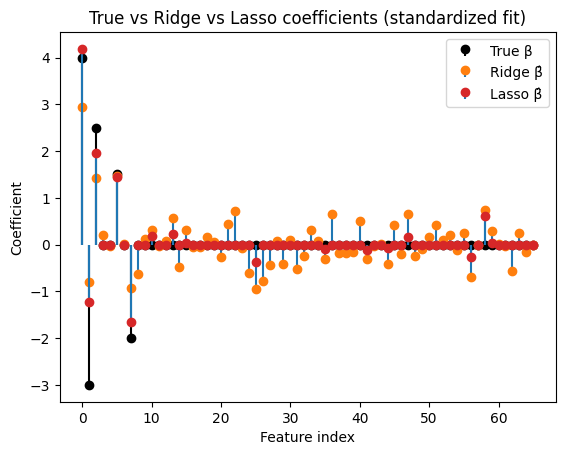


--- Test RMSE summary ---
OLS        : 18.829
Ridge      : 4.469
Lasso      : 2.712
Elastic Net: 2.712


In [ ]:
# Goal:
# 1) Sell the idea: when p approaches n (or p > n), X'X becomes singular (or ill-conditioned),
#    making OLS unstable / non-unique.
# 2) Show how L2 regularization (ridge) resolves this by making (X'X + λI) invertible.
# 3) Compare ridge vs lasso vs elastic net on prediction and sparsity.

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import matrix_rank, cond
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error

np.random.seed(7)

# -----------------------------
# 1) Simulate a "p close to n" setting
# -----------------------------
n = 100
p = 65   # p close to n -> trouble for X'X (often ill-conditioned)
sigma = 2.0

# Correlated features make the ill-conditioning even more obvious
rho = 0
Sigma = rho ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))
X = np.random.multivariate_normal(mean=np.zeros(p), cov=Sigma, size=n)

# Sparse-ish true signal
beta_true = np.zeros(p)
beta_true[:8] = [4, -3, 2.5, 0, 0, 1.5, 0, -2]  # a few non-zeros early on
y = X @ beta_true + sigma * np.random.randn(n)

# Train/test split (small n makes variance issues visible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=1)

# -----------------------------
# 2) Sell the instability: X'X is (nearly) singular / ill-conditioned
# -----------------------------
XtX = X_train.T @ X_train
print("n_train =", X_train.shape[0], "p =", X_train.shape[1])
print("rank(X_train) =", matrix_rank(X_train), "out of p =", p)
print("rank(X'X)      =", matrix_rank(XtX),      "out of p =", p)
print("condition number of X'X (large => unstable): {:.2e}".format(cond(XtX)))

# -----------------------------
# 3) Fit OLS and show it's wobbly
#    (Even if it fits, coefficients can be huge/unstable with collinearity.)
# -----------------------------
ols = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ols.fit(X_train, y_train)
yhat_ols = ols.predict(X_test)
rmse_ols = np.sqrt(mean_squared_error(y_test, yhat_ols))
coef_ols = ols.named_steps["model"].coef_

print("\nOLS RMSE:", rmse_ols)
print("OLS coefficient L2 norm (often inflated when ill-conditioned): {:.2f}".format(np.linalg.norm(coef_ols)))

# -----------------------------
# 4) Ridge: (X'X + λI) is invertible; shrinkage stabilizes estimates
# -----------------------------
# We'll use RidgeCV to pick λ by cross-validation.
alphas = np.logspace(-4, 4, 200)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge.fit(X_train, y_train)
yhat_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, yhat_ridge))

ridge_alpha = ridge.named_steps["model"].alpha_
coef_ridge = ridge.named_steps["model"].coef_
# np.linalg.solve(XtX + 0 * np.eye(p), X_train.T @ y_train)

print("\nRidge chosen alpha:", ridge_alpha)
print("Ridge RMSE:", rmse_ridge)
print("Ridge coefficient L2 norm (shrunk): {:.2f}".format(np.linalg.norm(coef_ridge)))

# -----------------------------
# 5) Lasso: L1 penalty => sparsity (feature selection)
# -----------------------------
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(alphas=None, cv=5, max_iter=20000, random_state=1))
])

lasso.fit(X_train, y_train)
yhat_lasso = lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, yhat_lasso))

lasso_alpha = lasso.named_steps["model"].alpha_
coef_lasso = lasso.named_steps["model"].coef_
n_nonzero_lasso = np.sum(coef_lasso != 0)

print("\nLasso chosen alpha:", lasso_alpha)
print("Lasso RMSE:", rmse_lasso)
print("Lasso non-zero coefficients:", n_nonzero_lasso, "out of", p)

# -----------------------------
# 6) Elastic Net: mix of ridge + lasso (good with correlated predictors)
# -----------------------------
enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],  # 1.0 == lasso
        alphas=np.logspace(-4, 2, 200),
        cv=5,
        max_iter=20000,
        random_state=1
    ))
])

enet.fit(X_train, y_train)
yhat_enet = enet.predict(X_test)
rmse_enet = np.sqrt(mean_squared_error(y_test, yhat_enet))

enet_alpha = enet.named_steps["model"].alpha_
enet_l1 = enet.named_steps["model"].l1_ratio_
coef_enet = enet.named_steps["model"].coef_
n_nonzero_enet = np.sum(coef_enet != 0)

print("\nElastic Net chosen alpha:", enet_alpha)
print("Elastic Net chosen l1_ratio:", enet_l1)
print("Elastic Net RMSE:", rmse_enet)
print("Elastic Net non-zero coefficients:", n_nonzero_enet, "out of", p)

# -----------------------------
# 7) Visual: coefficient paths (optional but very teachable)
#    Show shrinkage and sparsity on the same scale.
# -----------------------------
fig, ax = plt.subplots()
ax.stem(beta_true, linefmt='k-', markerfmt='ko', basefmt=" ", label="True β")
ax.stem(coef_ridge, linefmt='-', markerfmt='o', basefmt=" ", label="Ridge β̂")
ax.stem(coef_lasso, linefmt='-', markerfmt='o', basefmt=" ", label="Lasso β̂")
ax.set_title("True vs Ridge vs Lasso coefficients (standardized fit)")
ax.set_xlabel("Feature index")
ax.set_ylabel("Coefficient")
ax.legend()
plt.show()

# -----------------------------
# 8) Summary comparison
# -----------------------------
print("\n--- Test RMSE summary ---")
print(f"OLS        : {rmse_ols:.3f}")
print(f"Ridge      : {rmse_ridge:.3f}")
print(f"Lasso      : {rmse_lasso:.3f}")
print(f"Elastic Net: {rmse_enet:.3f}")
